<a href="https://colab.research.google.com/github/samrudhimadane6-creator/Customer-Segmentation/blob/main/Predictive_Analytics_Using_Historical_Data_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = {
    'Month': list(range(1, 21)),
    'Sales': [
        12000, 13500, 12800, 14500, 15200,
        16000, 15800, 17200, 18000, 17500,
        19000, 20500, 19800, 21500, 22500,
        23000, 24200, 25000, 26500, 27500
    ]
}

df = pd.DataFrame(data)

df

,Month,Sales
0,1,12000
1,2,13500
2,3,12800
3,4,14500
4,5,15200
5,6,16000
6,7,15800
7,8,17200
8,9,18000
9,10,17500


In [3]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (20, 2)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Month   20 non-null     int64
 1   Sales   20 non-null     int64
dtypes: int64(2)
memory usage: 452.0 bytes
None

Missing Values:
Month    0
Sales    0
dtype: int64


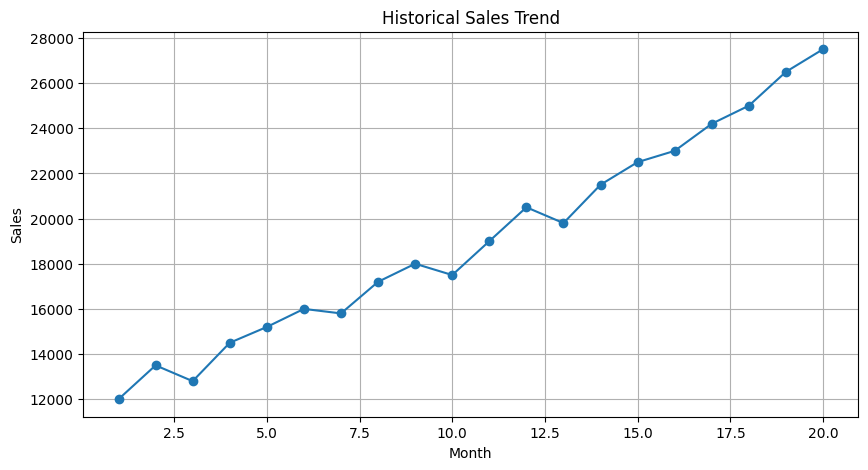

In [4]:
plt.figure(figsize=(10, 5))

plt.plot(df['Month'], df['Sales'], marker='o')

plt.title('Historical Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.grid(True)
plt.show()

In [5]:
X = df[['Month']]
y = df['Sales']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", len(X_train))
print("Testing Data:", len(X_test))

Training Data: 16
Testing Data: 4


In [7]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [8]:
y_pred = model.predict(X_test)

prediction_result = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

prediction_result

,Actual Sales,Predicted Sales
0,12000,11379.309305
1,25000,25069.295732
2,23000,23458.709094
3,13500,12184.602624


In [9]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 616.0232242497354
Root Mean Squared Error: 763.3385760776175
R2 Score: 0.9820280048045277


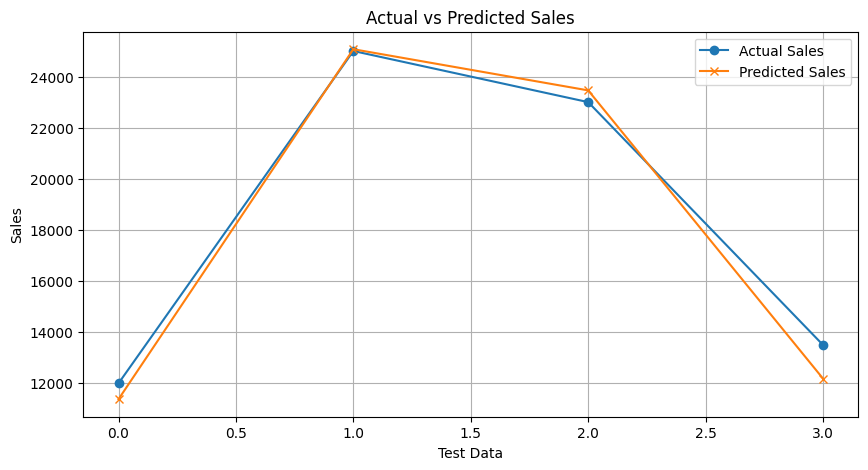

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(y_test.values, marker='o', label='Actual Sales')
plt.plot(y_pred, marker='x', label='Predicted Sales')

plt.title('Actual vs Predicted Sales')
plt.xlabel('Test Data')
plt.ylabel('Sales')

plt.legend()
plt.grid(True)

plt.show()

In [11]:
future_months = pd.DataFrame({
    'Month': [21, 22, 23, 24, 25]
})

future_predictions = model.predict(future_months)

future_result = pd.DataFrame({
    'Month': future_months['Month'],
    'Predicted Sales': future_predictions
})

future_result

,Month,Predicted Sales
0,21,27485.175690
1,22,28290.469009
2,23,29095.762328
3,24,29901.055648
4,25,30706.348967


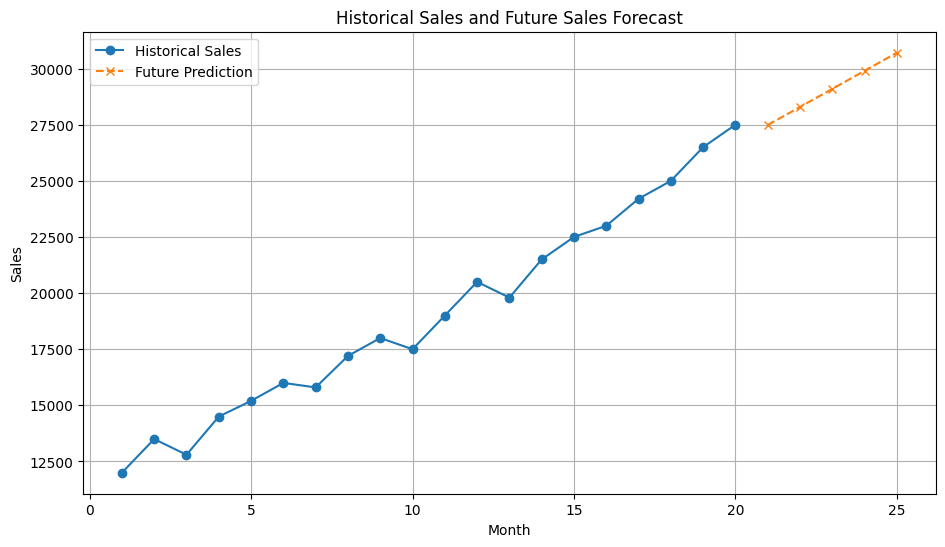

In [12]:
plt.figure(figsize=(11, 6))

plt.plot(
    df['Month'],
    df['Sales'],
    marker='o',
    label='Historical Sales'
)

plt.plot(
    future_months['Month'],
    future_predictions,
    marker='x',
    linestyle='--',
    label='Future Prediction'
)

plt.title('Historical Sales and Future Sales Forecast')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.legend()
plt.grid(True)

plt.show()